# Project 1 · Task 9 — A preventive treatment and survival curves

A preventive treatment changes the rate matrix (off-diagonals given; the diagonal is set so each row sums to zero). It **slows progression out of the post-surgery state** — the rate of leaving state 1 falls from $0.0085$ to $0.00475$ and the direct $2\to3$ pathway is removed — while the per-state death rates are unchanged. We simulate 1000 treated and 1000 untreated women (embedded chain, as in Task 7), estimate the survival function $S(t)=P(T>t)$ with the Kaplan–Meier estimator $\hat S(t)=(N-d(t))/N$, and compare. With no censoring this reduces to $\hat S(t)=1-F_n(t)$.

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
plt.rcParams["figure.figsize"] = (10, 4)

# States (0-indexed): 0 post-surgery, 1 local, 2 distant, 3 both, 4 death.
# Control = Task-7 matrix; treatment = Task-9 matrix (diagonal set so rows sum to 0).
Q_control = np.array([
    [-0.0085, 0.005,  0.0025, 0.0,   0.001],
    [ 0.0,   -0.014,  0.005,  0.004, 0.005],
    [ 0.0,    0.0,   -0.008,  0.003, 0.005],
    [ 0.0,    0.0,    0.0,   -0.009, 0.009],
    [ 0.0,    0.0,    0.0,    0.0,   0.0  ]])
Q_treat = np.array([
    [ 0.0, 0.0025, 0.00125, 0.0,   0.001],
    [ 0.0, 0.0,    0.0,     0.002, 0.005],
    [ 0.0, 0.0,    0.0,     0.003, 0.005],
    [ 0.0, 0.0,    0.0,     0.0,   0.009],
    [ 0.0, 0.0,    0.0,     0.0,   0.0  ]])
np.fill_diagonal(Q_treat, -Q_treat.sum(axis=1)) # project eq. 1: row sums = 0
DEATH = 4

In [ ]:
def simulate_lifetime(Q, start=0):
    """Lifetime until death via the embedded chain (sojourn Exp(-q_ii), then a jump)."""
    t, s = 0.0, start
    while s != DEATH:
        rate = -Q[s, s]
        t += -np.log(rng.random()) / rate # sojourn ~ Exp(rate): inverse transform
        p = Q[s] / rate; p[s] = 0.0 # jump probabilities -q_sj / q_ss
        s = rng.choice(5, p=p)
    return t


N = 1000
life_control = np.array([simulate_lifetime(Q_control) for _ in range(N)])
life_treat   = np.array([simulate_lifetime(Q_treat)   for _ in range(N)])

# Validation: simulated mean vs continuous phase-type mean E[T] = p0 (-Qs)^{-1} 1.
for name, life, Q in [("control", life_control, Q_control), ("treatment", life_treat, Q_treat)]:
    ET = np.array([1.0, 0, 0, 0]) @ np.linalg.inv(-Q[:4, :4]) @ np.ones(4)
    print(f"{name:9s}: simulated mean = {life.mean():6.1f}   theoretical E[T] = {ET:6.1f} months")

control  : simulated mean =  253.8   theoretical E[T] =  262.4 months
treatment: simulated mean =  341.2   theoretical E[T] =  346.3 months


### Kaplan–Meier survival

In [ ]:
def kaplan_meier(lifetimes):
    """Kaplan-Meier survival estimate S(t) = (N - d(t)) / N. With no censoring (every woman is followed to death) this equals 1 - F_n(t), the complementary empirical CDF. Returns the ordered death times and the survival just after each."""
    t = np.sort(lifetimes)
    n = len(t)
    S = 1.0 - np.arange(1, n + 1) / n
    return t, S


t_c, S_c = kaplan_meier(life_control)
t_t, S_t = kaplan_meier(life_treat)

# Survival at a few horizons makes the gap between the groups concrete.
print(f"{'t [months]':>10} {'no treatment':>14} {'treatment':>12}")
for h in (120, 240, 360):
    print(f"{h:>10} {np.mean(life_control > h):>14.3f} {np.mean(life_treat > h):>12.3f}")

t [months]   no treatment    treatment
       120          0.754        0.792
       240          0.463        0.567
       360          0.218        0.383


### Survival curves

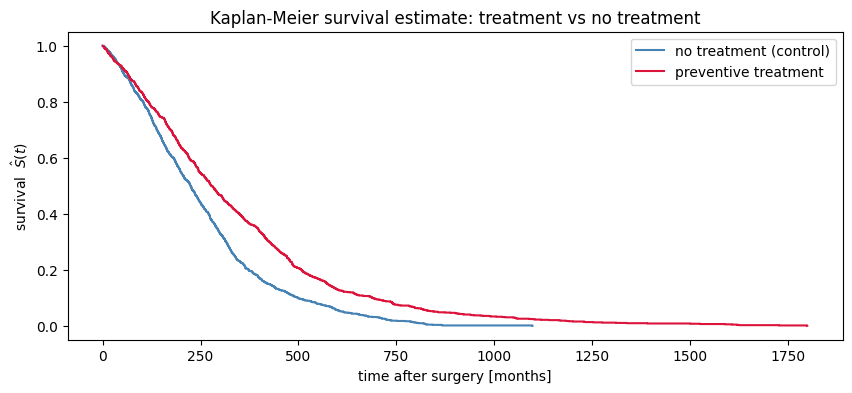

In [4]:
fig, ax = plt.subplots()
# prepend (t=0, S=1) so each curve starts from full survival
ax.step(np.r_[0, t_c], np.r_[1, S_c], where="post", color="steelblue", label="no treatment (control)")
ax.step(np.r_[0, t_t], np.r_[1, S_t], where="post", color="crimson",   label="preventive treatment")
ax.set_xlabel("time after surgery [months]")
ax.set_ylabel(r"survival  $\hat S(t)$")
ax.set_title("Kaplan-Meier survival estimate: treatment vs no treatment")
ax.legend()
plt.show()

**Result.** The treatment survival curve lies **above** the control curve at all times ($\hat S(240)\approx0.57$ vs $0.46$; $\hat S(360)\approx0.38$ vs $0.22$), and the mean lifetime rises from $\approx254$ to $\approx341$ months. The preventive treatment **appears to have a clear beneficial effect** on survival; a log-rank test (Task 10) would test its significance.